# RLHF mechanics: a frozen reward and PPO policy updates

CPU companion; no accelerator is required. TPU execution not validated.

- Keep three identities separate
- Collect actions before optimizing them
- Verify the changed-condition exercise and explain the limits of this fixture.

After fitting a reward model, how do its scores change a policy? We will collect actual sampled actions, freeze the behavior probabilities for each rollout batch and inspect improvement together with drift from a fixed reference.

## The idea

This lesson isolates RLHF mechanics in a small categorical bandit. A trainable policy is compared with rollout-time probabilities and a fixed reference, while a previously fitted reward model supplies frozen scores. Each role has a different update lifetime.

## Keep the four policy-and-reward roles distinct

The old policy probabilities stay fixed during the inner PPO updates for one rollout batch. They refresh when a new rollout is collected. The reference policy remains fixed across those rollouts and defines the KL comparison. The reward model is frozen during policy optimization.

Advantages and old probabilities should not quietly become new optimization targets during the inner update. This fixture uses an exact baseline and categorical KL; it does not contain a learned language-model critic or human-feedback collection pipeline.

Read reward, KL and action-probability panels together. Higher reward accompanied by a larger reference deviation is a tradeoff, not an unqualified success. Keep each plotted quantity tied to the actual policy state at measurement.

### Different objects have different update lifetimes

**Predict:** Which frozen object refreshes between rollout batches: old policy probabilities or the reference policy?

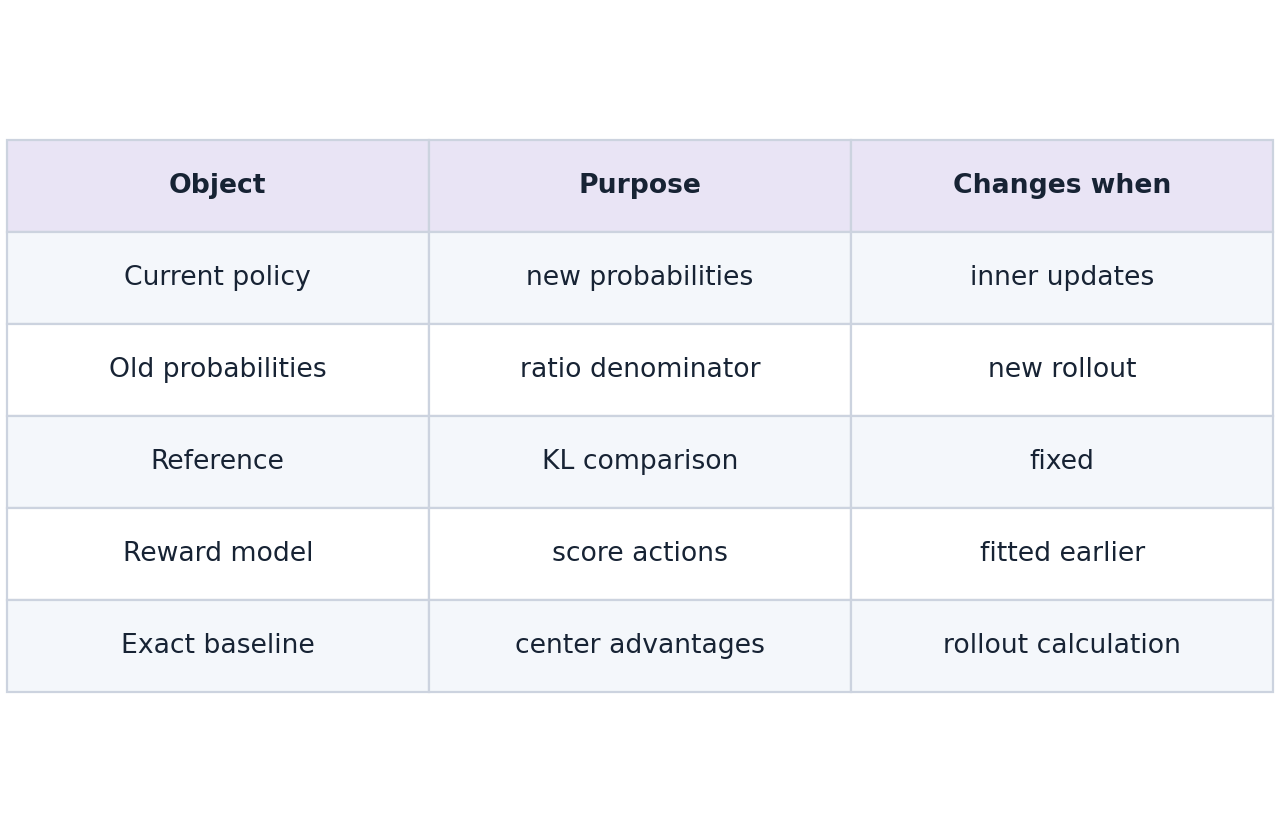

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Current parameters change within PPO updates. Old probabilities stay fixed for that rollout batch and refresh next rollout. The reference and reward remain fixed during policy training. This categorical fixture has an exact baseline, so no learned critic is shown.

### Pause and reason

Which frozen object refreshes between rollout batches: old policy probabilities or the reference policy?

<details><summary>Compare your reasoning</summary>

Old rollout-time probabilities refresh. The reference remains fixed under this lesson's contract. Confusing them changes the optimization objective.

</details>

## Before coding: identify four different objects

Keep a notebook table with current policy, old behavior policy, reference policy and reward model. The current policy changes on optimizer steps. The old policy is a snapshot taken before collecting the batch; its sampled-action log probabilities stay fixed while reusing that batch. The reference and reward model stay fixed for the whole experiment. Confusing old and reference makes even a numerically stable loop implement the wrong objective.

This lab is a bandit: one prompt, three terminal actions and no sequence credit assignment. It lets us calculate expectations exactly. Language PPO additionally needs token masks, rollout termination, value/advantage estimation and a generation pipeline; none of those can be inferred from this loop.

## Keep three identities separate

The reward model scores outputs. The reference policy anchors the desired deviation penalty and stays fixed. The old behavior policy generated the current batch and remains fixed only while that batch is reused. At the next rollout, old behavior updates to the new policy; the reference does not.

## Collect actions before optimizing them

The code samples terminal response actions from the current categorical policy. It stores their old log probabilities and computes an advantage using the frozen reward minus that policy’s exact expected reward. This exact baseline is available only because the action space is tiny; a general language system needs a suitable baseline or value estimator.

## Work a signed clipping example

For advantage $A=2$, ratio $\rho=1.5$, and clip interval $[0.8,1.2]$, the products are $3$ and $2.4$, so the minimum is $2.4$. Further increasing this ratio no longer improves that positive-advantage surrogate term. For $A=-2$ and $\rho=0.5$, the products are $-1$ and $-1.6$, so the minimum is $-1.6$.

Clipping limits the reward for moving in the advantageous direction too far on these samples. It does not freeze all probability changes or prove a global trust region. The explicit KL term can still contribute gradients when a surrogate term is clipped. Read the negative sign in the minimized loss carefully: we minimize negative surrogate plus a penalty.

## Why a baseline can help without changing the expected gradient

For sampled action $a$, the advantage here is reward minus the old policy’s exact expected reward. The baseline is independent of which action was sampled and is frozen for the update. Its expected contribution to the unclipped score-function gradient is zero because policy probabilities sum to one. Subtracting it can reduce sampling variance without changing that expected gradient.

Our three-action environment lets you enumerate this identity instead of trusting a noisy Monte Carlo comparison. The identity alone does not prove that arbitrary baselines, clipped multi-epoch surrogates or learned value estimators are unbiased. Preserve which estimator is being checked.

$$
\sum_a\pi(a)\nabla_\theta\log\pi(a)\,[r(a)-c]=\nabla_\theta\sum_a\pi(a)r(a)
$$

## Clip the surrogate with the advantage sign intact

Form a probability ratio from current and old log probabilities. Take the minimum of unclipped and clipped advantage products. Negative advantages reverse which bound matters; clipping only the ratio and maximizing it indiscriminately changes the algorithm. Advantages and behavior probabilities are detached.

$$
L=-\mathbb E\left[\min(\rho A,\operatorname{clip}(\rho,1-\epsilon,1+\epsilon)A)\right]+\beta D_{\mathrm{KL}}(\pi_\theta\Vert\pi_{\mathrm{ref}})
$$

## Measure reward and reference drift together

For this categorical bandit, compute the KL and expected learned reward exactly by summing over every action. The trainer includes this exact KL directly in the objective; it is not an implementation of every token-level reward-shaping variant. A higher reward with greater KL may be expected, and clipping does not guarantee a global trust region.

## Do not confuse reward optimization with alignment

The model can exploit a weak reward model. Keep independent evaluations, inspect unfavorable cases and fix reward/reference versions during a comparison. Actual human-feedback systems need human data provenance and held-out human judgments. This exercise demonstrates sampled policy optimization against a learned synthetic preference reward only.

## Use the exact solution as a bounded optimization reference

For a finite action space with positive reference probabilities, maximizing expected fixed reward minus $\beta$ times forward KL has optimum proportional to reference probability times $\exp(r/\beta)$. This is a reference for the regularized bandit problem, not a statement that forty sampled PPO iterations must reach it. Compute it with log-softmax for numerical stability.

Evaluate the regularized objective of your trained policy and this optimum. A gap can reflect finite optimization, clipping and sampled rollouts. A higher learned reward alone can come from excessive drift. Keep an independent task score and adversarial cases before carrying this pattern to a real reward model.

$$
\pi^*(a)=\frac{\pi_{\mathrm{ref}}(a)e^{r(a)/\beta}}{\sum_b\pi_{\mathrm{ref}}(b)e^{r(b)/\beta}}
$$

## 1. Define the reward likelihood and signed PPO loss

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def preference_loss(w, chosen, rejected):
    margin = (chosen-rejected) @ w
    return jnp.mean(jax.nn.softplus(-margin))

def ppo_loss(logits, old_logps, actions, advantages, reference_logps, beta=.1, clip=.2):
    logp = jax.nn.log_softmax(logits)
    ratios = jnp.exp(logp[actions] - jax.lax.stop_gradient(old_logps))
    advantages = jax.lax.stop_gradient(advantages)
    clipped = jnp.clip(ratios,1.-clip,1.+clip)
    surrogate = jnp.mean(jnp.minimum(ratios*advantages,clipped*advantages))
    # Exact categorical KL in this one-prompt, one-action teaching environment.
    kl = jnp.sum(jnp.exp(logp)*(logp-jax.lax.stop_gradient(reference_logps)))
    return -surrogate + beta*kl

Keep reward fitting and policy loss separate. Inside policy loss, old probabilities and advantages are constants for differentiation.

## 2. Fit and freeze reward, then identify reference state

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
features=jnp.array([[1.,0.],[0.,1.],[-1.,-1.]])
chosen=features[jnp.array([0,0,1])];rejected=features[jnp.array([1,2,2])]
reward_w=jnp.zeros(2)
reward_step=jax.jit(jax.grad(lambda w:preference_loss(w,chosen,rejected)))
for _ in range(100):reward_w=reward_w-.1*reward_step(reward_w)
rewards=jax.lax.stop_gradient(features@reward_w)
# A fixed reference policy and a learned reward, with one terminal response action.
reference=jax.nn.log_softmax(jnp.array([.2,0.,-.2]));theta=jnp.array([.2,0.,-.2])
reference_copy=np.asarray(reference).copy();key=jax.random.key(11);history=[];kl_history=[]
step=jax.jit(jax.value_and_grad(ppo_loss))

The reference is stored before policy updates. This step also creates the sampling key and independent reward model.

## 3. Collect rollouts and reuse each batch correctly

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
for iteration in range(40):
    old=jax.nn.log_softmax(theta);probs=jnp.exp(old)
    key,draw=jax.random.split(key);actions=jax.random.categorical(draw,old,shape=(128,))
    old_selected=jax.lax.stop_gradient(old[actions])
    advantage=jax.lax.stop_gradient(rewards[actions]-jnp.sum(probs*rewards))
    for _ in range(3):
        _,g=step(theta,old_selected,actions,advantage,reference,.2,.2);theta=theta-.15*g
    logp=jax.nn.log_softmax(theta)
    history.append(float(jnp.sum(jnp.exp(logp)*rewards)))
    kl_history.append(float(jnp.sum(jnp.exp(logp)*(logp-reference))))
np.testing.assert_array_equal(reference,reference_copy)
initial_reward=float(jnp.sum(jnp.exp(reference)*rewards))
assert history[-1]>initial_reward and kl_history[-1]>0
# Independent finite-action expectation: no evaluation sampling error here.
np.testing.assert_allclose(history[-1],sum(float(a)*float(b) for a,b in zip(jnp.exp(logp),rewards)),rtol=1e-6)
print('Reward initial/final and final KL:',initial_reward,history[-1],kl_history[-1])
print('Synthetic preference bandit with actual sampled PPO updates; no human ratings or language-generation claim.')

Reward initial/final and final KL: 0.28191882371902466 1.9185447692871094 0.7824773192405701
Synthetic preference bandit with actual sampled PPO updates; no human ratings or language-generation claim.


Each outer iteration collects a fresh batch; each inner step reuses its saved behavior probabilities. Plot points occur after a rollout batch, unlike pre-update loss curves in other lessons.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np

def preference_loss(w, chosen, rejected):
    margin = (chosen-rejected) @ w
    return jnp.mean(jax.nn.softplus(-margin))

def ppo_loss(logits, old_logps, actions, advantages, reference_logps, beta=.1, clip=.2):
    logp = jax.nn.log_softmax(logits)
    ratios = jnp.exp(logp[actions] - jax.lax.stop_gradient(old_logps))
    advantages = jax.lax.stop_gradient(advantages)
    clipped = jnp.clip(ratios,1.-clip,1.+clip)
    surrogate = jnp.mean(jnp.minimum(ratios*advantages,clipped*advantages))
    # Exact categorical KL in this one-prompt, one-action teaching environment.
    kl = jnp.sum(jnp.exp(logp)*(logp-jax.lax.stop_gradient(reference_logps)))
    return -surrogate + beta*kl

features=jnp.array([[1.,0.],[0.,1.],[-1.,-1.]])
chosen=features[jnp.array([0,0,1])];rejected=features[jnp.array([1,2,2])]
reward_w=jnp.zeros(2)
reward_step=jax.jit(jax.grad(lambda w:preference_loss(w,chosen,rejected)))
for _ in range(100):reward_w=reward_w-.1*reward_step(reward_w)
rewards=jax.lax.stop_gradient(features@reward_w)
# A fixed reference policy and a learned reward, with one terminal response action.
reference=jax.nn.log_softmax(jnp.array([.2,0.,-.2]));theta=jnp.array([.2,0.,-.2])
reference_copy=np.asarray(reference).copy();key=jax.random.key(11);history=[];kl_history=[]
step=jax.jit(jax.value_and_grad(ppo_loss))
for iteration in range(40):
    old=jax.nn.log_softmax(theta);probs=jnp.exp(old)
    key,draw=jax.random.split(key);actions=jax.random.categorical(draw,old,shape=(128,))
    old_selected=jax.lax.stop_gradient(old[actions])
    advantage=jax.lax.stop_gradient(rewards[actions]-jnp.sum(probs*rewards))
    for _ in range(3):
        _,g=step(theta,old_selected,actions,advantage,reference,.2,.2);theta=theta-.15*g
    logp=jax.nn.log_softmax(theta)
    history.append(float(jnp.sum(jnp.exp(logp)*rewards)))
    kl_history.append(float(jnp.sum(jnp.exp(logp)*(logp-reference))))
np.testing.assert_array_equal(reference,reference_copy)
initial_reward=float(jnp.sum(jnp.exp(reference)*rewards))
assert history[-1]>initial_reward and kl_history[-1]>0
# Independent finite-action expectation: no evaluation sampling error here.
np.testing.assert_allclose(history[-1],sum(float(a)*float(b) for a,b in zip(jnp.exp(logp),rewards)),rtol=1e-6)
print('Reward initial/final and final KL:',initial_reward,history[-1],kl_history[-1])
print('Synthetic preference bandit with actual sampled PPO updates; no human ratings or language-generation claim.')


Reward initial/final and final KL: 0.28191882371902466 1.9185447692871094 0.7824773192405701
Synthetic preference bandit with actual sampled PPO updates; no human ratings or language-generation claim.


Expected: Sampled PPO updates increase exact expected learned reward while the reference stays unchanged.

## RLHF mechanics: a frozen reward and PPO policy updates — recorded experiment

Predict: Which action gains probability as reward rises, and why does that also change reference KL?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={'panels':[{'kind':'line','xlabel':'completed PPO rollout batches','ylabel':'expected learned reward','series':[{'label':'exact policy expectation','x':list(range(1,len(history)+1)),'y':history}]},{'kind':'line','xlabel':'completed PPO rollout batches','ylabel':'KL to fixed reference (nats)','series':[{'label':'exact categorical KL','x':list(range(1,len(kl_history)+1)),'y':kl_history}]}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']

extra_panel={'kind':'bar','x':[0,1,2],'labels':['action 0','action 1','action 2'],'series':[{'label':'fixed reference','y':np.asarray(jnp.exp(reference)).tolist()},{'label':'trained policy','y':np.asarray(jnp.exp(logp)).tolist()}],'xlabel':'terminal response action','ylabel':'probability','title':'How increased reward redistributes action probability'}
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}


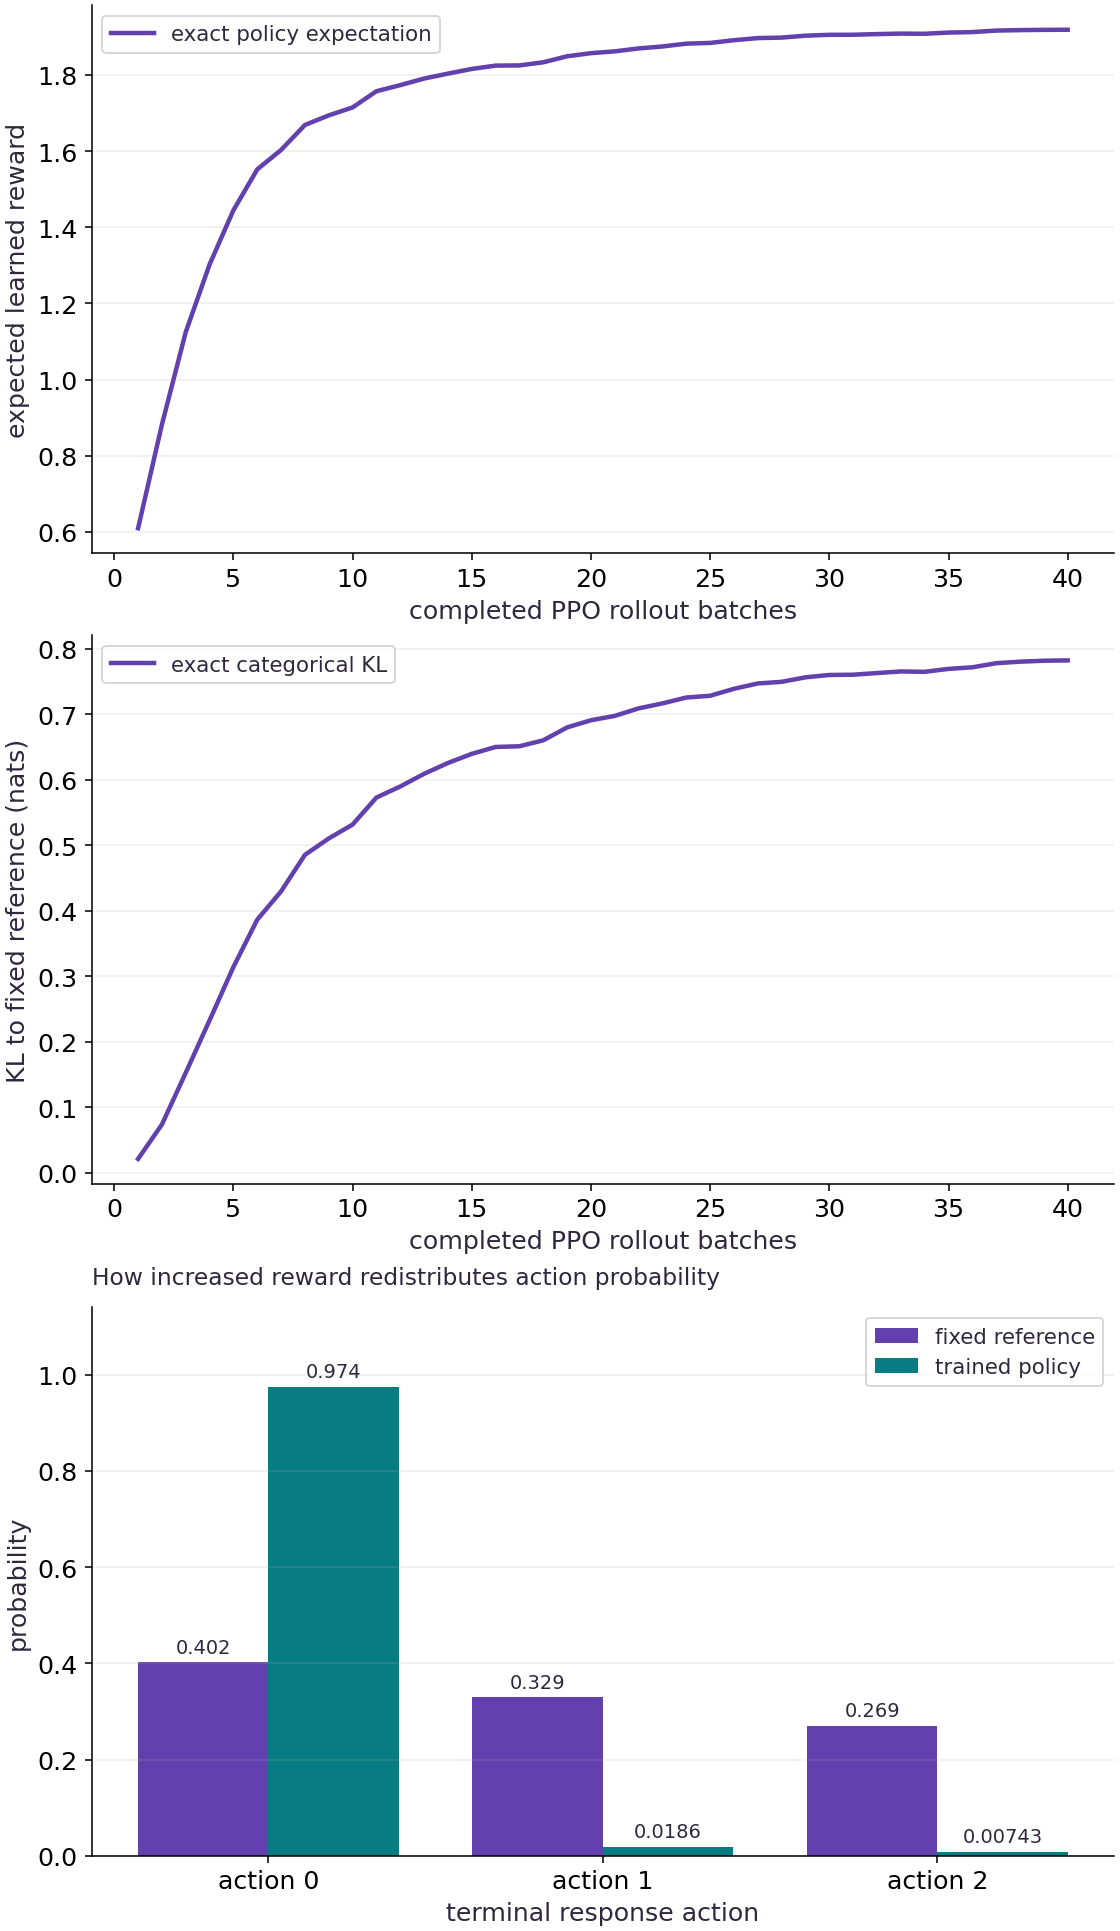

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The top panel shows exact expected learned reward after each rollout batch, rising toward the highest-scored action. The bottom panel shows exact KL in nats to the fixed reference. The final reward is about $1.92$, with KL about $0.78$. The axes are different quantities and must not be added as if they shared units.

The third panel compares reference and final action probabilities; each series sums to one. Probability moves toward action zero, the response favored by the learned reward. The other actions lose probability, explaining the rising expected reward and KL in the first two panels. Reward is measured in the learned score scale, KL in nats and these bars in probability: do not combine their heights. This is a finite synthetic policy distribution, not a measure of human approval.

### Connect it to the computation

The policy concentrates on the action favored by the learned reward, which also moves it away from the reference. These deterministic expectation measurements evaluate a policy trained from random rollouts; they are not sampled human preference scores or a safety assessment.

## Inspect both clipping directions

Predict: For a positive advantage with ratio above the upper bound, and a negative advantage below the lower bound, which product is retained?

In [7]:
ratios=np.array([1.5,.5]);advantages=np.array([2.,-2.])
terms=np.minimum(ratios*advantages,np.clip(ratios,.8,1.2)*advantages)
np.testing.assert_allclose(terms,[2.4,-1.6])
print('Clipped surrogate terms:',terms)

Clipped surrogate terms: [ 2.4 -1.6]


Expected: The terms are [2.4, -1.6].

The negative-advantage case selects the more negative product. This is why clipping must be applied inside the signed surrogate.

## Enumerate the baseline cancellation

Predict: Does subtracting a fixed baseline change the exact policy gradient before clipping?

In [8]:
probe=jnp.array([.3,-.2,.1]);probe_probs=jax.nn.softmax(probe)
constant=float(jnp.sum(probe_probs*rewards))
score_jacobian=jax.jacrev(jax.nn.log_softmax)(probe)
enumerated=jnp.sum(probe_probs[:,None]*(rewards-constant)[:,None]*score_jacobian,axis=0)
exact=jax.grad(lambda logits:jnp.sum(jax.nn.softmax(logits)*rewards))(probe)
np.testing.assert_allclose(enumerated,exact,atol=1e-6)
print('Enumerated baseline score gradient matches exact expected-reward gradient.')

Enumerated baseline score gradient matches exact expected-reward gradient.


Expected: The two gradients agree up to float32 rounding.

Enumeration removes sampling error. This tests the unclipped estimator identity; it does not assert that every clipped update equals exact gradient ascent.

## Your exercise

Check the KL at the fixed reference and compare it with the final policy’s exact KL.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
zero_kl=float(jnp.sum(jnp.exp(reference)*(reference-reference)))
assert zero_kl==0. and kl_history[-1]>zero_kl
print('Reference/final KL:',zero_kl,kl_history[-1])

Reference/final KL: 0.0 0.7824773192405701


## Verify detached behavior information · Transfer

Differentiate the objective with respect to supplied old log probabilities and advantages; both must be fixed within this update.

Hint: Use argnums to inspect only those two inputs.

In [11]:
# Write your attempt here.

## Reference reasoning

Detaching is not enough if you recompute old probabilities after every optimizer step. Store their values at collection time and verify identity across all epochs on that batch.

In [12]:
old_grad,adv_grad=jax.grad(ppo_loss,argnums=(1,3))(theta,old_selected,actions,advantage,reference,.2,.2)
np.testing.assert_array_equal(old_grad,np.zeros(old_grad.shape))
np.testing.assert_array_equal(adv_grad,np.zeros(adv_grad.shape))
print('Behavior log probabilities and advantages are detached.')

Behavior log probabilities and advantages are detached.


## Compare with the finite-action regularized optimum · Challenge

Compute the analytic optimum for beta 0.2, then compare its regularized objective with the trained policy and the reference.

Hint: Evaluate expected reward minus beta times KL for all three policies, and compute the optimum in log space.

In [13]:
# Write your attempt here.

## Reference reasoning

An independently derived optimum bounds this finite-action objective. It does not qualify language generation or the reward model’s judgment.

In [14]:
beta=.2
optimal_logp=jax.nn.log_softmax(reference+rewards/beta)
def regularized(logp):return jnp.sum(jnp.exp(logp)*rewards)-beta*jnp.sum(jnp.exp(logp)*(logp-reference))
optimum=float(regularized(optimal_logp));trained=float(regularized(logp));baseline=float(regularized(reference))
assert optimum>=trained-1e-5 and optimum>=baseline-1e-5
print('Regularized objective reference/trained/optimum:',baseline,trained,optimum)

Regularized objective reference/trained/optimum: 0.28191882371902466 1.7620493173599243 1.7987911701202393


## Checkpoint

Which policy is refreshed for the next rollout batch?

1. The behavior policy follows the current policy; the reference policy remains frozen.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If ratios always equal one during repeated updates, inspect whether old log probabilities are being recomputed. If reward grows while external quality falls, investigate reward exploitation instead of declaring alignment.

## Evidence

Keep reward/reference identity, collected old probabilities, signed clipping checks, exact reward/KL history and detached behavior information.

## Carry forward

- For advantage $A=2$, ratio $\rho=1.5$, and clip interval $[0.8,1.2]$, the products are $3$ and $2.4$, so the minimum is $2.4$. Further increasing this ratio no longer improves that positive-advantage surrogate term. For $A=-2$ and $\rho=0.5$, the products are $-1$ and $-1.6$, so the minimum is $-1.6$.
- For a finite action space with positive reference probabilities, maximizing expected fixed reward minus $\beta$ times forward KL has optimum proportional to reference probability times $\exp(r/\beta)$. This is a reference for the regularized bandit problem, not a statement that forty sampled PPO iterations must reach it. Compute it with log-softmax for numerical stability.

## Primary references

- [InstructGPT and RLHF](https://arxiv.org/abs/2203.02155)
- [PPO](https://arxiv.org/abs/1707.06347)